# Imports

In [1]:
import pandas as pd
import math
import random
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             mean_absolute_error, mean_squared_error, r2_score)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
import time
import plotly.express as px
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import ConfusionMatrixDisplay
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 10

# Load datasets

In [2]:
X_train = pd.read_csv("../data/processed/X_train_processed.csv")
X_test = pd.read_csv("../data/processed/X_test_processed.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")

In [3]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(75090, 469)
(25031, 469)
(75090,)
(25031,)


In [4]:
def clean_feature_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.replace("<", "LT_", regex=False)
        .str.replace(">", "GT_", regex=False)
        .str.replace("[", "", regex=False)
        .str.replace("]", "", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
    )
    return df

X_train = clean_feature_names(X_train)
X_test = clean_feature_names(X_test)

# Baseline Model

In [5]:
# --- Logistic Regression---
print("--- Training Logistic Regression ---")
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
print(classification_report(y_test, y_pred_log))

# --- Decission Tree ---
print("\n--- Training Decission Tree ---")
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
print(classification_report(y_test, y_pred_tree))

--- Training Logistic Regression ---
              precision    recall  f1-score   support

         <30       0.37      0.03      0.06      2839
         >30       0.52      0.36      0.42      8887
          NO       0.61      0.85      0.71     13305

    accuracy                           0.58     25031
   macro avg       0.50      0.41      0.40     25031
weighted avg       0.55      0.58      0.53     25031


--- Training Decission Tree ---
              precision    recall  f1-score   support

         <30       0.16      0.14      0.15      2839
         >30       0.41      0.40      0.40      8887
          NO       0.59      0.61      0.60     13305

    accuracy                           0.48     25031
   macro avg       0.39      0.39      0.39     25031
weighted avg       0.48      0.48      0.48     25031



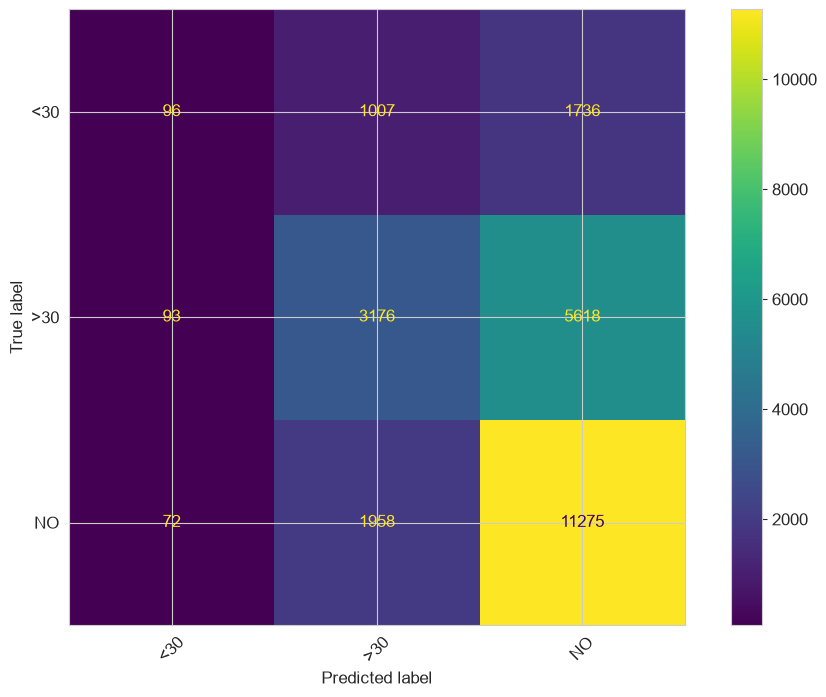

In [6]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    xticks_rotation=45
)

plt.show()

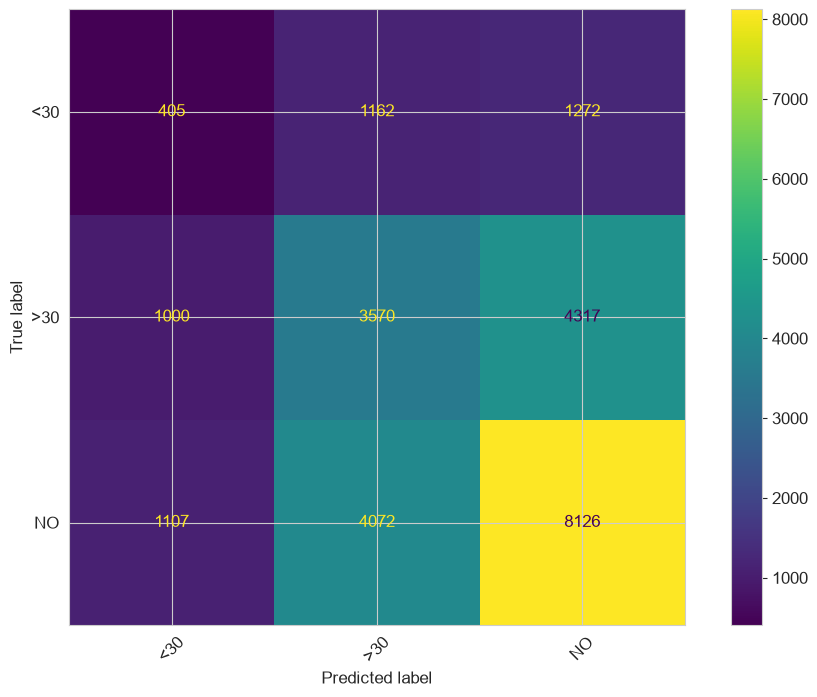

In [7]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    xticks_rotation=45
)

plt.show()

**Conclusions** 
- The <30 class is the hardest to predict.
- Class imbalanced influence predictions. Both models tend to favor the majority class. Logistic regression achieved a higher F1 score for being more conservative and choosing "No readmission" more frequently. 
- Decission Tree was more sensitive with the minority class, but had a greater amount of False Positives. 

# Random Forest

In [8]:
random_forest = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced", n_jobs=-1)

print("Training Random Forest")
start_time_simple_rf = time.time()
random_forest.fit(X_train, y_train)
end_time_simple_rf = time.time()
simple_rf_train_time = end_time_simple_rf - start_time_simple_rf
print(f"Training completed in {simple_rf_train_time:.4f} seconds.")

rf_pred = random_forest.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Precission in test: {rf_accuracy:.4f}")
print("Model Classification Report")
print(classification_report(y_test, rf_pred))

Training Random Forest
Training completed in 9.3906 seconds.
Precission in test: 0.5665
Model Classification Report
              precision    recall  f1-score   support

         <30       0.34      0.10      0.16      2839
         >30       0.47      0.52      0.49      8887
          NO       0.64      0.70      0.67     13305

    accuracy                           0.57     25031
   macro avg       0.49      0.44      0.44     25031
weighted avg       0.55      0.57      0.55     25031



**Conclusions**

- Random Forest model performs a little better. It is not as conservative as the Logistic Regression model, but still manages a higher F1-Score compared to the Decission Tree. 
- Still, the model presents a high amount of false positives, and has trouble detecting the <30 class.

# XGBoost

In [7]:
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train.squeeze())
y_test_enc = label_encoder.transform(y_test.squeeze())

xgboost = xgb.XGBClassifier(objective='multi:softprob',
                                    eval_metric='logloss',
                                    num_class=3,
                                    n_estimators=200,
                                    learning_rate=0.1,
                                    max_depth=3,
                                    random_state=42,
                                    n_jobs=2)

start_time = time.time()
xgboost.fit(X_train, y_train_enc)
end_time = time.time()
train_time_xgb_initial = end_time - start_time

y_train_pred_xgb = xgboost.predict(X_train)
y_test_pred_xgb = xgboost.predict(X_test)

print(f"Training time (XGBoost inicial): {train_time_xgb_initial:.4f} seconds")
train_pred_label = label_encoder.inverse_transform(y_train_pred_xgb)
test_pred_label = label_encoder.inverse_transform(y_test_pred_xgb)
print("\nClassification report (XGBoost - Train):")
print(classification_report(y_train, train_pred_label))
print("\nClassification report (XGBoost - Test):")
print(classification_report(y_test, test_pred_label))

Training time (XGBoost inicial): 10.1180 seconds

Classification report (XGBoost - Train):
              precision    recall  f1-score   support

         <30       0.65      0.03      0.06      8518
         >30       0.52      0.37      0.43     26658
          NO       0.61      0.85      0.71     39914

    accuracy                           0.59     75090
   macro avg       0.59      0.42      0.40     75090
weighted avg       0.58      0.59      0.54     75090


Classification report (XGBoost - Test):
              precision    recall  f1-score   support

         <30       0.45      0.02      0.04      2839
         >30       0.51      0.36      0.42      8887
          NO       0.61      0.85      0.71     13305

    accuracy                           0.58     25031
   macro avg       0.52      0.41      0.39     25031
weighted avg       0.55      0.58      0.53     25031



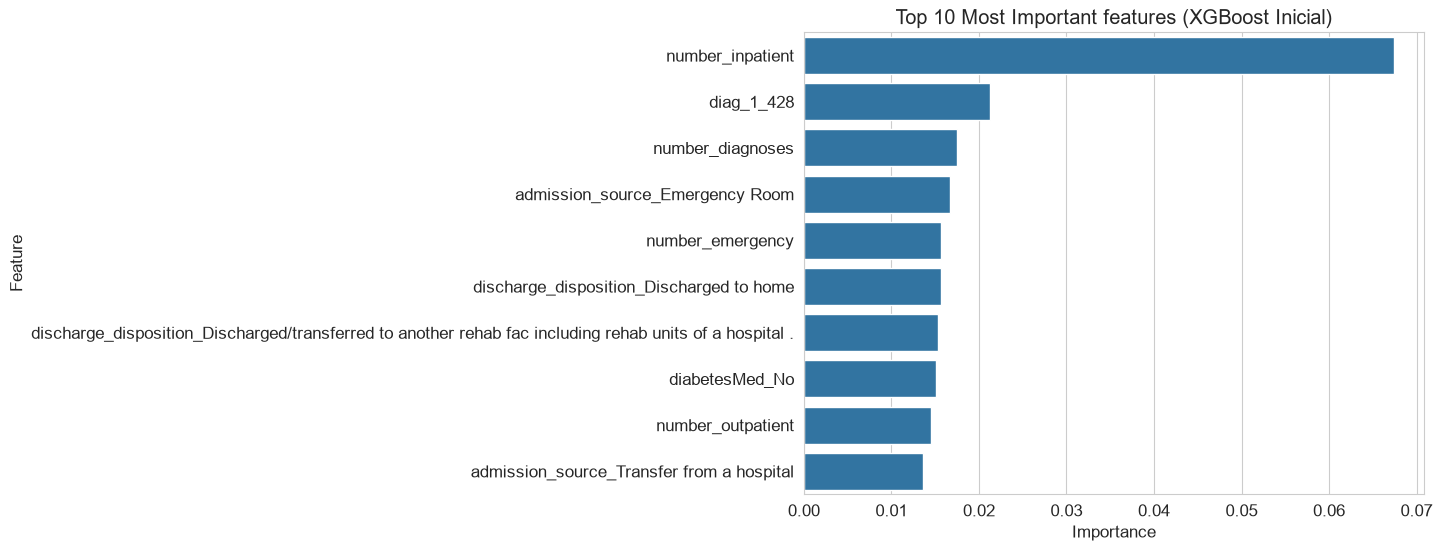

In [10]:
fi_xgb = pd.DataFrame(columns=["Feature", "Importance"])
fi_xgb["Feature"] = X_train.columns
fi_xgb["Importance"] = xgboost.feature_importances_
fi_xgb = fi_xgb.sort_values("Importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(y=fi_xgb.Feature, x=fi_xgb.Importance)
plt.title('Top 10 Most Important features (XGBoost Inicial)')
plt.show()

**Conclusions**
- XGBoost model does not show signs of overfitting looking at the minimal difference between Training and Testing F1-scores
- <30 class is still the hardest to predict, having a very low recall for the model.
- Model performs slightly better than previous ones. 
- Most important features for prediction are based on healthcare utilization, specially number_inpatient.

# Hyperparameter tunning

## RandomForest

In [12]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=2
    ),
    param_grid=rf_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=2,
    verbose=2
)

In [13]:
start_time = time.time()

rf_grid.fit(X_train, y_train)

end_time = time.time()

print(f"GridSearch completed in {end_time - start_time:.2f} seconds")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
GridSearch completed in 479.77 seconds


In [14]:
print("Best parameters:")
print(rf_grid.best_params_)

Best parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [15]:
print("Best CV Macro F1:")
print(rf_grid.best_score_)

Best CV Macro F1:
0.4622360932239942


In [17]:
best_rf = rf_grid.best_estimator_

rf_pred = best_rf.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         <30       0.26      0.22      0.24      2839
         >30       0.47      0.51      0.49      8887
          NO       0.66      0.65      0.66     13305

    accuracy                           0.55     25031
   macro avg       0.46      0.46      0.46     25031
weighted avg       0.55      0.55      0.55     25031



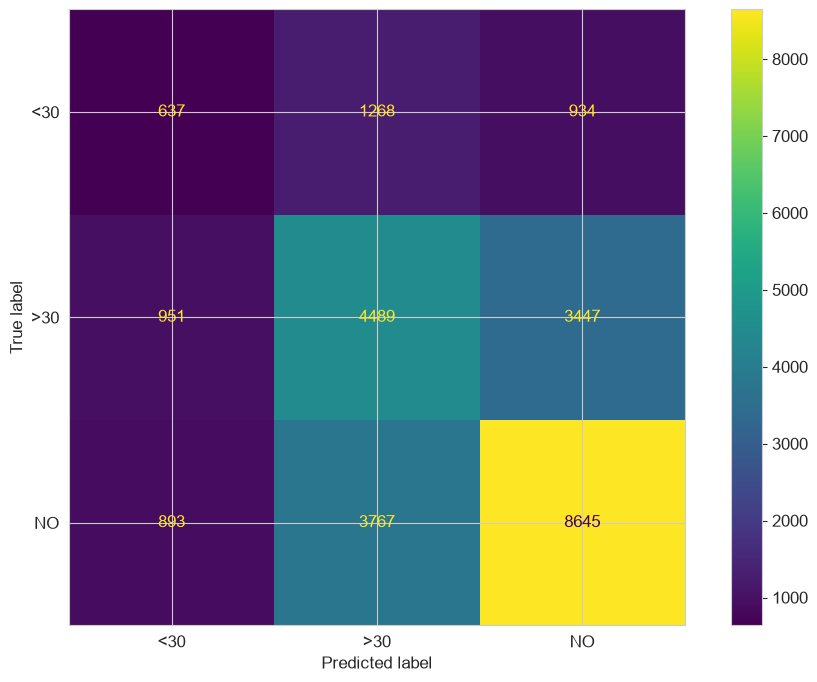

In [18]:
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    cmap="viridis"
)

**Conclusions**

- Hyperparameter tunning improved the model´s ability to classify the minority class (<30).
- Overall accuracy is slightly decreaesed as a trade-off for increasing the recall on <30
- Optimizing gave a more balanced classification, reducing the bias for the majority class.

## XGBoost

In [5]:
xgb_param_grid = {
    "n_estimators": [400, 500],
    "max_depth": [7, 9],
    "learning_rate": [0.05, 0.1, 0.15],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=2
    ),
    param_grid=xgb_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=2,
    verbose=2
)

In [8]:
start_time = time.time()

xgb_grid.fit(X_train, y_train_enc)

end_time = time.time()

print(f"GridSearch completed in {end_time - start_time:.2f} seconds")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
GridSearch completed in 855.11 seconds


In [9]:
print("Best parameters:")
print(xgb_grid.best_params_)

Best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.15, 'max_depth': 7, 'n_estimators': 400}


In [10]:
print("Best CV Macro F1:")
print(xgb_grid.best_score_)

Best CV Macro F1:
0.41807127705438907


In [11]:
best_xgb = xgb_grid.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

y_pred_xgb_labels = label_encoder.inverse_transform(y_pred_xgb)

print(classification_report(y_test, y_pred_xgb_labels))

              precision    recall  f1-score   support

         <30       0.40      0.06      0.10      2839
         >30       0.50      0.43      0.46      8887
          NO       0.62      0.80      0.70     13305

    accuracy                           0.58     25031
   macro avg       0.51      0.43      0.42     25031
weighted avg       0.55      0.58      0.55     25031



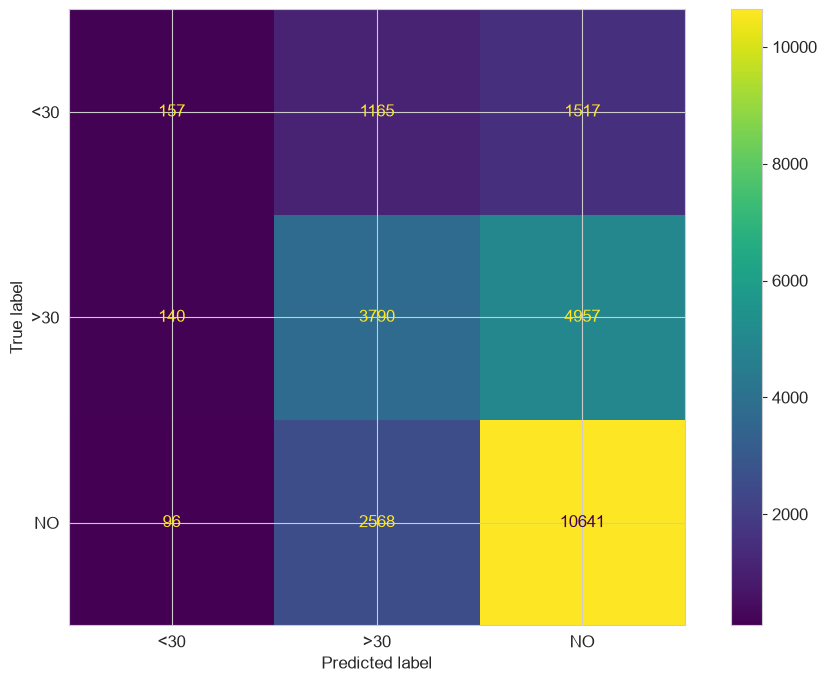

In [12]:
y_pred_labels = label_encoder.inverse_transform(y_pred_xgb)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_labels,
    cmap="viridis"
)

**Conclusions**

- Optimization gave a slight improvement over base XGBoost
- The model continues to favor the majority class, with low recall for <30 readmission
- Available features provide limited information for this model to predict early readmission

# Conclusions

In [14]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        0.58,
        0.48,
        0.57,
        0.55,
        0.58,
        0.58
    ],
    "Macro F1": [
        0.40,
        0.39,
        0.44,
        0.46,
        0.39,
        0.42
    ],
    "Recall (<30)": [
        0.03,
        0.14,
        0.10,
        0.22,
        0.02,
        0.06
    ],
    "Notes": [
        "Baseline linear model",
        "Simple tree",
        "Ensemble baseline",
        "Best balance between classes",
        "Boosting baseline",
        "Improved after tuning"
    ]
})

results

,Model,Accuracy,Macro F1,Recall (<30),Notes
0,Logistic Regression,0.58,0.40,0.03,Baseline linear model
1,Decision Tree,0.48,0.39,0.14,Simple tree
2,Random Forest,0.57,0.44,0.10,Ensemble baseline
3,Tuned Random Forest,0.55,0.46,0.22,Best balance between classes
4,XGBoost,0.58,0.39,0.02,Boosting baseline
5,Tuned XGBoost,0.58,0.42,0.06,Improved after tuning


Multiple machine learning models were developed and compared to predict hospital readmission for diabetes using a dataset from 130 US hospitals.

Models included a baseline of Logistic Regression and Decission Tree. Ensemble methods (Random Forest and XGBoost) got a better performance compared to the baseline, and hyperparameter tunning for the same models further improved the results obtained. 

Optimized Random Forest achieved the best balance between overall predictive performance and detection of the minority class (patients readmitted within 30 days of last visit). XGBoost was a highly competitive model, but favored the majority class of no readmission.

All models struggled to clasify the minority class (<30), meaning the complexity of the problem lies not in the model used, but the difficulty for the prediction task and the information provided by available features. Early readmission might be correlated to other factors only partially captured by clinical data provided in a hospital. 

This project demostrates a complete machine learning workflow, including data cleaning, feature engineering, preprocessing and model development, including a critical evaluation of model performance. This project highlights the importance of systematic experimentation and careful interpretation of results, going beyond identifying an overall best performing model when working with real-life healthcare prediction problems. 